In [32]:
import pandas as pd
import numpy as np

In [2]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


In [8]:
#X = scout_car.drop(columns=['Price'])
X = scout_car

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

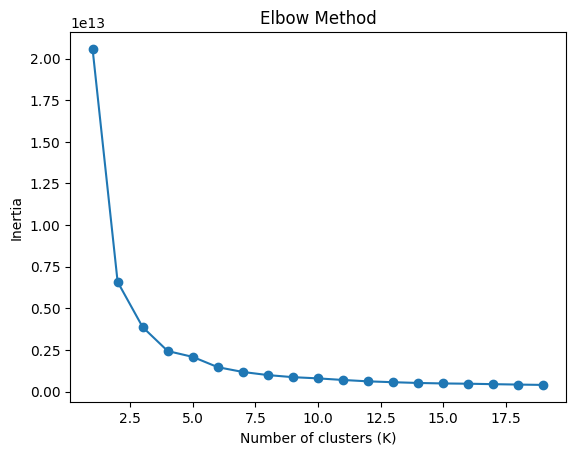

In [10]:
inertias = []
for i in range(1, 20):  
    kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 20), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

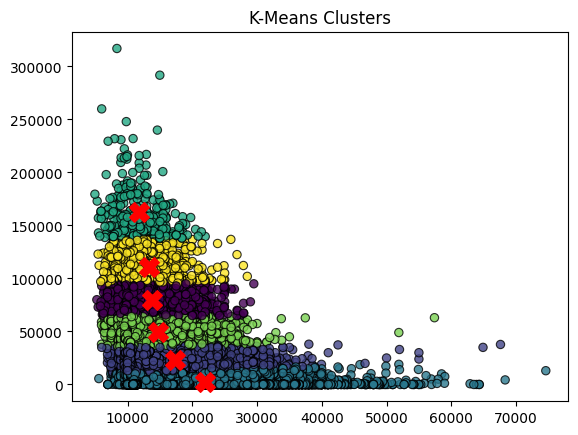

In [20]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.8)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clusters")
plt.show()

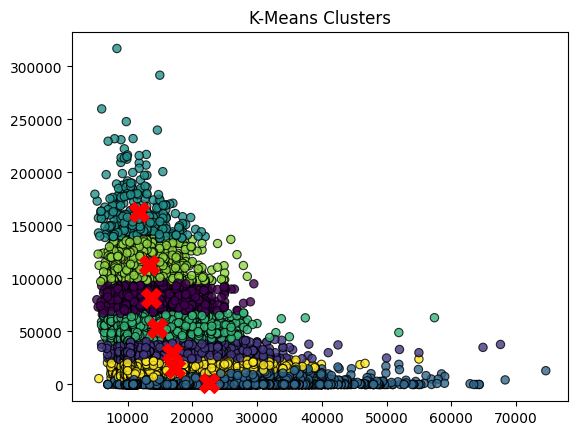

In [21]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init='auto')
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.8)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clusters")
plt.show()

# PCA

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


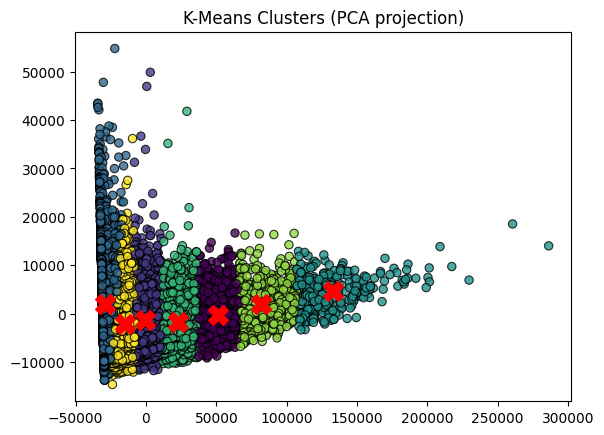

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.8)
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clusters (PCA projection)")
plt.show()

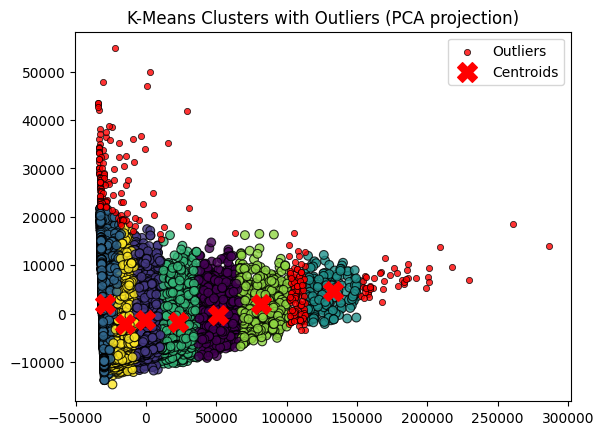

In [48]:
# Compute distances of each point to its assigned cluster centroid
distances = np.linalg.norm(X - centroids[labels], axis=1)

# Define outliers as the top 2% farthest from their centroid
threshold = np.percentile(distances, 98)
outliers = distances > threshold

# Plot regular points
plt.scatter(X_pca[~outliers, 0], X_pca[~outliers, 1],
            c=labels[~outliers], cmap='viridis',
            alpha=0.8, s=40, edgecolors='black', linewidth=0.8)

# Plot outliers separately in red
plt.scatter(X_pca[outliers, 0], X_pca[outliers, 1],
            c='red', marker='o', alpha=0.8, s=20, label='Outliers', edgecolors='black', linewidth=0.6)

# Plot centroids
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clusters with Outliers (PCA projection)")
plt.legend()
plt.show()

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


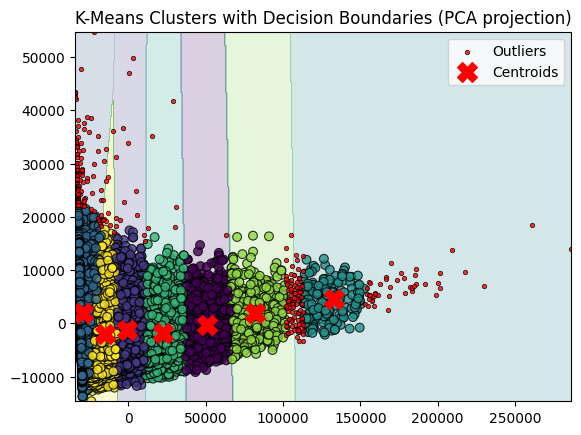

In [47]:
import numpy as np
from matplotlib.colors import ListedColormap

# Create a mesh grid covering the PCA space
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict cluster labels for each point
Z = kmeans.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot the decision boundary regions
plt.contourf(xx, yy, Z, alpha=0.2, cmap='viridis')

# Plot regular points
plt.scatter(X_pca[~outliers, 0], X_pca[~outliers, 1],
            c=labels[~outliers], cmap='viridis',
            alpha=0.8, s=40, edgecolors='black', linewidth=0.8)

# Plot outliers separately in red
plt.scatter(X_pca[outliers, 0], X_pca[outliers, 1],
            c='red', marker='o', alpha=0.8, s=10, label='Outliers', edgecolors='black', linewidth=0.6)

# Plot centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clusters with Decision Boundaries (PCA projection)")
plt.legend()
plt.show()

In [23]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)
print(pca_components)

        Price        KM  Registration  Horsepower (kW)  Previous Owners  \
PC1 -0.083139  0.996535     -0.000020         0.000006         0.000003   
PC2  0.996231  0.083056      0.000016         0.003025        -0.000011   

     Inspection new  Warranty (months)    # of Doors    # of Seats  \
PC1   -3.470493e-07          -0.000014  3.445368e-07 -2.154395e-07   
PC2   -1.338381e-06          -0.000021  1.691542e-05  1.869754e-05   

     Displacement (cc)  ...  Country version_Poland  Country version_Spain  \
PC1           0.002439  ...           -3.746547e-08           2.648691e-07   
PC2           0.018074  ...            4.546688e-08          -7.411203e-07   

     Upholstery Material_Full leather  Upholstery Material_Other  \
PC1                      2.621932e-07               1.397829e-07   
PC2                      1.888468e-05              -3.590591e-07   

     Upholstery Material_Part leather  Upholstery Material_Velour  \
PC1                     -7.455615e-08               -1

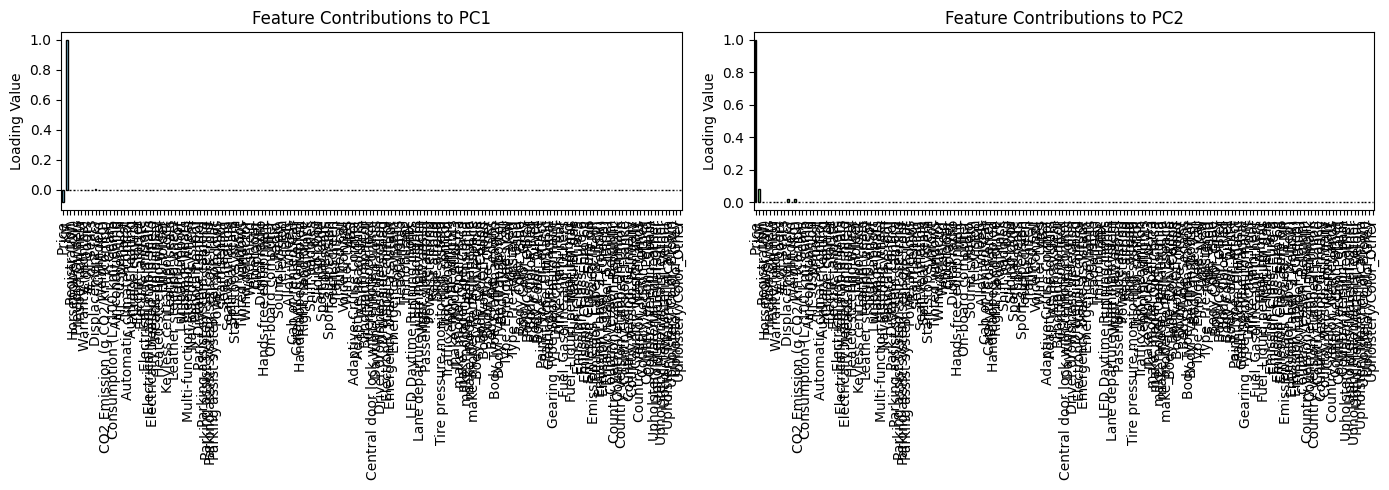

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Get PCA loadings (contributions of each feature to the PCs)
pca_components = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)

# Plot loadings for PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca_components.loc['PC1'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title("Feature Contributions to PC1")
axes[0].set_ylabel("Loading Value")
axes[0].tick_params(axis='x', rotation=90)

pca_components.loc['PC2'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Feature Contributions to PC2")
axes[1].set_ylabel("Loading Value")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [25]:
pca_components

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
PC1,-0.083139,0.996535,-0.000020,0.000006,0.000003,-3.470493e-07,-0.000014,3.445368e-07,-2.154395e-07,0.002439,...,-3.746547e-08,2.648691e-07,2.621932e-07,1.397829e-07,-7.455615e-08,-1.863927e-08,-5.889958e-09,4.332486e-08,5.888181e-07,-2.658979e-07
PC2,0.996231,0.083056,0.000016,0.003025,-0.000011,-1.338381e-06,-0.000021,1.691542e-05,1.869754e-05,0.018074,...,4.546688e-08,-7.411203e-07,1.888468e-05,-3.590591e-07,7.277935e-06,-5.437673e-08,3.939964e-07,3.733823e-06,-9.920403e-07,1.850826e-06


# HCA

# DBSCAN